## EKF: Nonlinear Van der Pol Oscillator

### Continuous‐Time Physics Derivation

The Van der Pol oscillator with a time‐varying nonlinearity parameter satisfies  
$$
\ddot x(t) \;-\;\mu(t)\,\bigl[1 - x(t)^2\bigr]\,\dot x(t)\;+\;x(t)\;=\;0,
$$  
where  
$$
\mu(t)=1.0 \;+\;0.5\,\sin\bigl(0.1\,t\bigr).
$$  
Define the state vector  
$$
x(t)=\begin{bmatrix}x_1(t)\\[4pt]x_2(t)\end{bmatrix}
=\begin{bmatrix}x(t)\\[4pt]\dot x(t)\end{bmatrix}.
$$  
Then the continuous‐time, time‐varying dynamics are  
$$
\dot x(t)
=\underbrace{\begin{bmatrix}
0 & 1 \\[6pt]
-\,1 & 0
\end{bmatrix}}_{\!A_0}\!x(t)
\;+\;\underbrace{\begin{bmatrix}0\\[4pt](1-x_1^2)\,x_2\end{bmatrix}}_{\!f_{\mathrm{nl}}(x,t)},
$$  
or more compactly  
$$
\dot x(t)=f\bigl(x(t),t\bigr), 
\quad
f\bigl(x,t\bigr)=
\begin{bmatrix}
x_2\\[4pt]
\mu(t)\,\bigl(1 - x_1^2\bigr)\,x_2 - x_1
\end{bmatrix}.
$$  

Its Jacobian w.r.t. \(x\) is  
$$
F\bigl(x,t\bigr)
=\frac{\partial f}{\partial x}
=\begin{bmatrix}
0 & 1 \\[6pt]
-\,2\,\mu(t)\,x_1\,x_2 -1 \;\;&\;\;\mu(t)\,\bigl(1 - x_1^2\bigr)
\end{bmatrix}.
$$

---

### Continuous‐Time System with Noise

Inject zero‐mean process noise \(w_c(t)\) into the second (acceleration) channel and measurement noise \(v_c(t)\):
$$
\boxed{
\begin{aligned}
\dot x(t)&=f\bigl(x(t),t\bigr)\;+\;L\,w_c(t),\\[4pt]
y(t)&=H\,x(t)\;+\;v_c(t),
\end{aligned}
}
$$
where
$$
L=\begin{bmatrix}0\\1\end{bmatrix},
\quad
H=\begin{bmatrix}1 & 0\end{bmatrix},
$$
$$
w_c(t)\sim\mathcal{N}\bigl(0,\,Q_c\,\delta(t-\tau)\bigr),
\quad
v_c(t)\sim\mathcal{N}\bigl(0,\,R\,\delta(t-\tau)\bigr).
$$

---

### EKF Covariance Propagation & Update

Between measurements, the error covariance \(P(t)\) evolves as
$$
\frac{d}{dt}P(t)
=F\bigl(x(t),t\bigr)\,P(t)+P(t)\,F\bigl(x(t),t\bigr)^T+L\,Q_c\,L^T.
$$

At each discrete measurement time \(t_k\):
$$
\begin{aligned}
K(t_k)&=P^-(t_k)\,H^T\bigl[H\,P^-(t_k)\,H^T+R\bigr]^{-1},\\[6pt]
P^+(t_k)&=\bigl[I-K(t_k)\,H\bigr]\,P^-(t_k).
\end{aligned}
$$

---

### Summary

$$
\boxed{
\begin{aligned}
\dot x(t)&=f\bigl(x(t),t\bigr)+L\,w_c(t),\\[4pt]
y_k&=H\,x(t_k)+v_c(t_k),
\end{aligned}
}
\quad
f\bigl(x,t\bigr)=\begin{bmatrix}
x_2\\[4pt]
\bigl[1+0.5\sin(0.1t)\bigr](1-x_1^2)x_2 - x_1
\end{bmatrix}.
$$

---





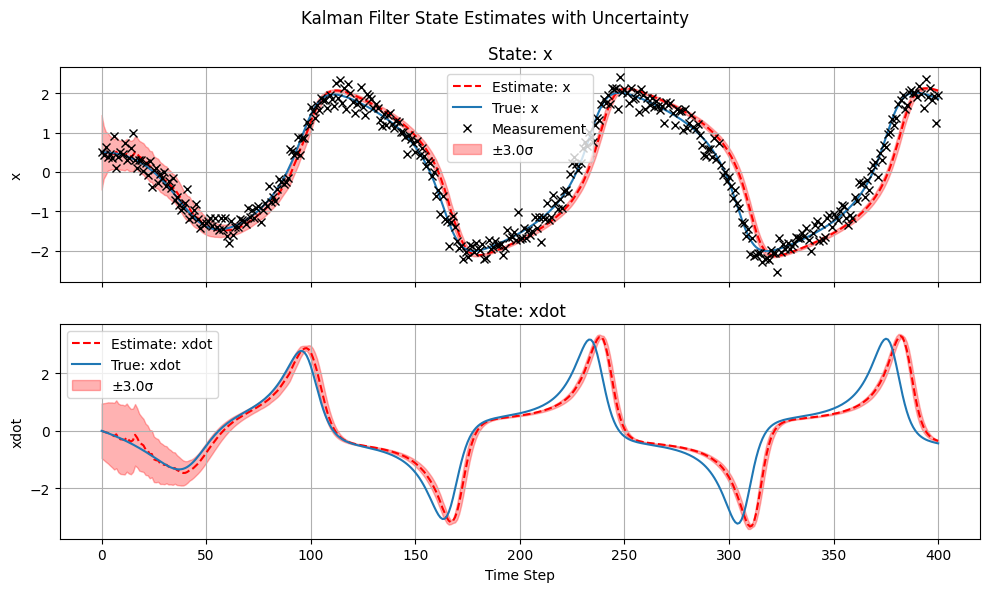

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import solve_ivp

# 1) Parameters & sampling
dt  = 0.05
Q_c = 1e-4            # continuous spectral density
Q   = Q_c * dt * np.eye(2)  # discrete process‐noise cov
R   = np.array([[0.1]])     # measurement‐noise cov
t   = np.arange(0, 20+dt, dt)

# 2) Continuous‐time Van der Pol for truth (RK4 via solve_ivp)
def vdp_rhs(t, x):
    mu = 1.0 + 0.5*np.sin(0.1*t)
    return [x[1], mu*(1-x[0]**2)*x[1] - x[0]]

sol = solve_ivp(vdp_rhs, (t[0], t[-1]), [0.5, 0.0],
                t_eval=t, method='RK45', rtol=1e-8)
x_true = sol.y.T  # shape (len(t),2)

# 3) Noisy measurements
y = x_true[:,0] + 0.2*np.random.randn(len(t))
y_df = pd.DataFrame(y, columns=['x'])

# 4) EKF definitions (discrete‐time, time‐varying)
def f_d(x, u, t):
    mu = 1.0 + 0.5*np.sin(0.1*t)
    f = np.array([ x[1],
                   mu*(1-x[0]**2)*x[1] - x[0] ])
    return x + f*dt

def F_d(x, u, t):
    mu = 1.0 + 0.5*np.sin(0.1*t)
    J = np.array([
        [0.0,                          1.0],
        [-2*mu*x[0]*x[1] - 1.0,
         mu*(1-x[0]**2)]
    ])
    return np.eye(2) + J*dt

H = lambda x,u: np.array([[1.0, 0.0]])
h = lambda x,u: np.array([x[0]])

ekf_vdp = pk.EKF(
    f=f_d, h=h,
    Q=Q, R=R,
    dt=dt,
    system_type=pk.SystemType.DISCRETE_TIME_VARYING
)

# 5) Run filter
x0 = pd.Series([0.5,0.0], index=['x','xdot'])
P0 = 0.1*np.eye(2)
x_est, P_est = ekf_vdp.run(x0, P0, y_df, F_d, H)

# 6) Truncate & plot
N = len(t)
x_est = x_est.iloc[:N]
P_est = P_est[:N]
y_df  = y_df.iloc[:N]

ekf_vdp.plot_kf_predictions(
    x_est, P_est,
    x_true_df=pd.DataFrame(x_true, columns=['x','xdot']),
    y_df=y_df
)